In [19]:
#%pip install pandas matplotlib seaborn sqlalchemy ipython-sql

This notebook reproduces the empirical results in:

**“ ”**

It constructs the key variables from market data and replicates the figures used in the main text.

All notation follows the blog post.

In [20]:
import pandas as pd
from sqlalchemy import create_engine

engine = create_engine('sqlite:///obstfeld.db')

csv_files = ['lunc-usd-max.csv', 'ustc-usd-max.csv']

for file in csv_files:
    try:
        table_name = file.split('.')[0]

        df = pd.read_csv(file)
        df.to_sql(table_name, engine, if_exists='replace', index=False)
        print('Successful')
    except Exception as e:
        print('Failed due to {e}')

Successful
Successful


## Mapping Theory to Data

From the model:

- $x_t$: redemptions  
- $p_t$: LUNA price  
- $\frac{x_t}{p_t}$: minting pressure  

In the data:

- Redemptions are proxied by changes in UST supply  
- LUNA supply is computed as market cap divided by price  
- Reflexivity ratio is constructed as:

$$
\frac{x_t}{p_t}
$$

## Data Construction

We use price and market capitalization data for UST and LUNA.

From this:

- Supply = market cap / price  
- Redemptions = $\Delta$ UST supply 

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

query = """
WITH luna AS (SELECT datetime(REPLACE(snapped_at, ' UTC', '')) AS t, price AS L_price, market_cap/price AS L_supply
FROM "lunc-usd-max"
WHERE datetime(REPLACE(snapped_at, ' UTC', '')) BETWEEN '2022-05-05' AND '2022-05-14'), 

ust AS ( select *, lag(U_supply) over (order by t) as prev_U_supply
from
(SELECT datetime(REPLACE(snapped_at, ' UTC', '')) AS t, price AS U_price, market_cap/price AS U_supply
FROM "ustc-usd-max"
WHERE datetime(REPLACE(snapped_at, ' UTC', '')) BETWEEN '2022-05-05' AND '2022-05-14')
)

SELECT l.t, l_price, l_supply, u_price, u_supply, prev_u_supply - u_supply as redemptions, (prev_u_supply - u_supply)/l_price as ref_ratio
from luna l
left join ust u
on l.t = u.t
order by l.t
"""

df = pd.read_sql(query, engine)
df['t'] = pd.to_datetime(df['t'])
df = df.sort_values('t')


### UST Price

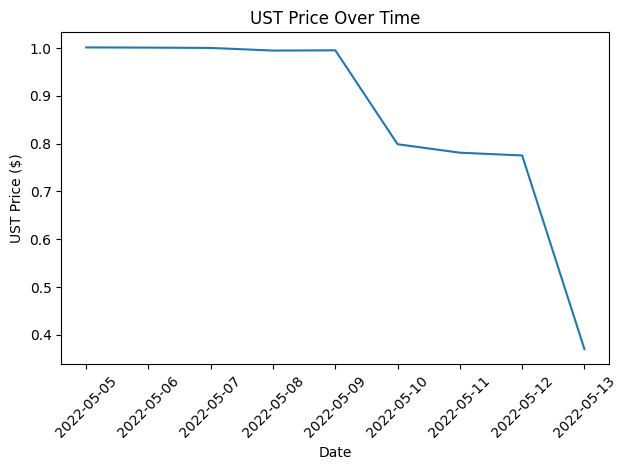

In [22]:
plt.figure()
plt.plot(df['t'], df['U_price'])
plt.title("UST Price Over Time")
plt.xlabel("Date")
plt.ylabel("UST Price ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Luna Price ($p_t$) Mapped Against Luna Supply ($L_t$)

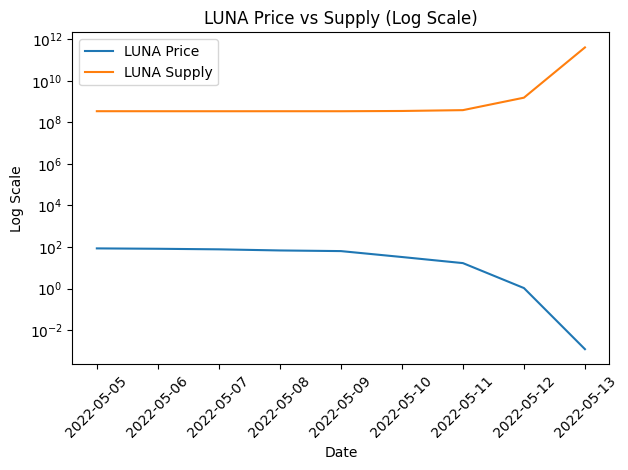

In [23]:
plt.figure()

plt.plot(df['t'], df['L_price'], label='LUNA Price')
plt.plot(df['t'], df['L_supply'], label='LUNA Supply')

plt.yscale('log')

plt.title("LUNA Price vs Supply (Log Scale)")
plt.xlabel("Date")
plt.ylabel("Log Scale")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Reflexivity Pressure ($x_t / p_t$)


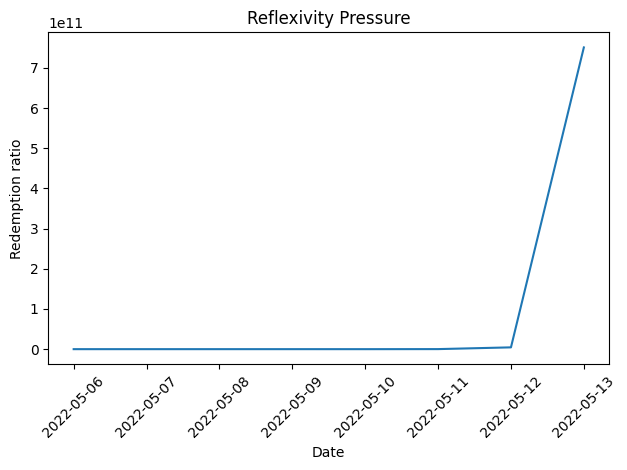

In [24]:
plt.figure()
plt.plot(df['t'], df['ref_ratio'])
plt.title("Reflexivity Pressure")
plt.xlabel("Date")
plt.ylabel("Redemption ratio")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The reflexivity ratio increases sharply during the collapse.

As $p_t$ declines, each unit of redemption requires minting more LUNA, amplifying supply expansion and reinforcing downward price pressure.